# Comparing enrichment-score methods on scRNA-seq

`ov.es` ships GPU-accelerated drop-in replacements for `decoupler.mt`'s eleven scoring kernels. Every method exposes the same `(adata, signatures, engine)` API, so swapping the algorithm is a one-line change. This tutorial walks through every method on the same gene set, shows the math behind it, and visualises CPU vs GPU side by side.

The dataset and pathway are the same as in the [AUCell tutorial](../t_aucell.ipynb).

## Part.1 Data preprocess

In [1]:
# omicverse exposes scoring kernels under ov.es and applies its default plotting
# style (font, colour palette) when you call ov.style().
import numpy as np
import omicverse as ov
ov.style()

/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


🔬 Starting plot initialization...
🧬 Detecting GPU devices…
✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3
      Memory: 79.1 GB | Compute: 9.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.1.3rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



In [2]:
# Mouse embryonic pancreas scRNA-seq (Bastidas-Ponce et al., scvelo bundle).
# Ships with a precomputed UMAP in adata.obsm['X_umap'], so ov.pl.umap works
# without re-running PCA / neighbours / UMAP.
adata = ov.datasets.pancreatic_endocrinogenesis()
adata

🔍 Downloading data to ./data/endocrinogenesis_day15.h5ad...


Downloading:   0%|                                                                                             | 0.00/52.5M [00:00<?, ?B/s]

Downloading:  21%|█████████████████▉                                                                   | 11.1M/52.5M [00:00<00:00, 110MB/s]

Downloading:  43%|████████████████████████████████████▉                                                | 22.8M/52.5M [00:00<00:00, 114MB/s]

Downloading:  66%|███████████████████████████████████████████████████████▉                             | 34.5M/52.5M [00:00<00:00, 116MB/s]

Downloading:  88%|██████████████████████████████████████████████████████████████████████████▉          | 46.3M/52.5M [00:00<00:00, 116MB/s]

Downloading: 100%|█████████████████████████████████████████████████████████████████████████████████████| 52.5M/52.5M [00:00<00:00, 116MB/s]

✅ Download completed
 Loading data from ./data/endocrinogenesis_day15.h5ad


✅ Successfully loaded: 3696 cells × 27998 genes


AnnData object with n_obs × n_vars = 3696 × 27998
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score'
    var: 'highly_variable_genes'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca'
    obsm: 'X_pca', 'X_umap'
    layers: 'spliced', 'unspliced'
    obsp: 'distances', 'connectivities'

In [3]:
# Subsample to keep mdt / udt CPU comparisons tractable; the UMAP pattern
# survives the downsampling, and the relative CPU↔GPU agreement isn't a
# function of the cell count.
rng = np.random.default_rng(0)
adata = adata[rng.choice(adata.n_obs, size=300, replace=False)].copy()

# Flag every gene as 'robust' before preprocess — we want all genes available
# for scoring, not the HVG subset the default pipeline would otherwise keep.
adata.var['robust'] = True
adata = ov.pp.preprocess(adata, target_sum=1e4)

🔍 [2026-05-18 04:06:20] Running preprocessing in 'cpu' mode...
Begin robust gene identification


    After filtration, 14182/27998 genes are kept.
    Among 14182 genes, 14182 genes are robust.
✅ Robust gene identification completed successfully.
Begin size normalization: shiftlog and HVGs selection pearson

🔍 Count Normalization:
   Target sum: 10000.0
   Exclude highly expressed: True
   Max fraction threshold: 0.2
   ⚠️ Excluding 1 highly-expressed genes from normalization computation
   Excluded genes: ['Ghrl']

✅ Count Normalization Completed Successfully!
   ✓ Processed: 300 cells × 14,182 genes
   ✓ Runtime: 0.02s

🔍 Highly Variable Genes Selection (Experimental):
   Method: pearson_residuals
   Target genes: 2,000
   Theta (overdispersion): 100



✅ Experimental HVG Selection Completed Successfully!
   ✓ Selected: 2,000 highly variable genes out of 14,182 total (14.1%)
   ✓ Results added to AnnData object:
     • 'highly_variable': Boolean vector (adata.var)
     • 'highly_variable_rank': Float vector (adata.var)
     • 'highly_variable_nbatches': Int vector (adata.var)
     • 'highly_variable_intersection': Boolean vector (adata.var)
     • 'means': Float vector (adata.var)
     • 'variances': Float vector (adata.var)
     • 'residual_variances': Float vector (adata.var)
    Time to analyze data in cpu: 0.42 seconds.
✅ Preprocessing completed successfully.
    Added:
        'highly_variable_features', boolean vector (adata.var)
        'means', float vector (adata.var)
        'variances', float vector (adata.var)
        'residual_variances', float vector (adata.var)
        'counts', raw counts layer (adata.layers)
    End of size normalization: shiftlog and HVGs selection pearson

╭─ SUMMARY: preprocess ───────────────────

In [4]:
# Load the GO Biological Process 2021 collection as a dict of {pathway: [genes]}.
pathway_dict = ov.utils.geneset_prepare(
    'genesets/GO_Biological_Process_2021.txt', organism='Mouse',
)
# We score a single representative pathway for the comparison; ov.es methods
# accept any number of signatures and write one column per signature.
geneset_name = 'response to vitamin (GO:0033273)'
signatures = {geneset_name: pathway_dict[geneset_name]}

   - Geneset 'GO_Biological_Process_2021' missing locally; auto-downloading via ov.utils.download_pathway_database()...
......Pathway Geneset download start: GO_Biological_Process_2021
Using Stanford mirror for GO_Biological_Process_2021
🔍 Downloading data to ./genesets/GO_Biological_Process_2021.txt...


Downloading: |                                                                                                  | 0.00/0.00 [00:00<?, ?B/s]

Downloading: |                                                                                         | 1.54M/0.00 [00:00<00:00, 19.0MB/s]

✅ Download completed
......Pathway Geneset download start: GO_Cellular_Component_2021
Using Stanford mirror for GO_Cellular_Component_2021
🔍 Downloading data to ./genesets/GO_Cellular_Component_2021.txt...


Downloading: |                                                                                                  | 0.00/0.00 [00:00<?, ?B/s]

...

Downloading: |                                                                                            | 63.9k/? [00:00<00:00, 89.2MB/s]

✅ Download completed
......Pathway Geneset download start: Reactome_2022
Using Stanford mirror for Reactome_2022
🔍 Downloading data to ./genesets/Reactome_2022.txt...


Downloading: |                                                                                                  | 0.00/0.00 [00:00<?, ?B/s]

Downloading: |                                                                                          | 781k/0.00 [00:00<00:00, 23.6MB/s]

✅ Download completed
✅ Pathway Geneset download finished!
......Other Genesets can be downloaded from https://maayanlab.cloud/Enrichr/#libraries


## Part.2 The unified API: `ov.es.decoupler`

Every method below is callable via `ov.es.<name>(...)` directly. But there's also a single dispatcher that takes the algorithm as a parameter:

```python
ov.es.decoupler(adata, signatures=sigs, method='aucell', engine='gpu')
# ↑ equivalent to ov.es.aucell(adata, signatures=sigs, engine='gpu')
```

Why have both? The dispatcher is handy when the choice of algorithm needs to be a runtime parameter — e.g. for benchmarking sweeps, configuration-driven pipelines, or agent tool-call interfaces. `ov.es.decoupler` is registered with omicverse's function registry so it can be discovered/invoked by agents.

In [5]:
# Same call, two ways. ov.es.decoupler dispatches by method string; the kwargs
# (signatures, engine, tmin, ...) are forwarded verbatim to the underlying kernel.
ov.es.decoupler(adata, signatures=signatures, method='aucell', engine='gpu', tmin=3)
# ov.es.aucell  (adata, signatures=signatures,                 engine='gpu', tmin=3)

# Per-method scores land in adata.obsm['score_<method>'] as a (cells × signatures)
# DataFrame; p-values (when applicable) go to adata.obsm['padj_<method>'].
adata.obsm['score_aucell'].head()


╭─ SUMMARY: aucell ──────────────────────────────────────────────────╮
│  Duration: 0.4079s                                                 │
│  Shape:    300 x 14,182 (Unchanged)                                │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● OBSM   │ ✚ score_aucell (dataframe, 300x1)                      │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯


,response to vitamin (GO:0033273)
GTGCAGCAGCTATGCT,0.00000
CAGATCAAGCTGTTCA,0.00000
GCAGCCAGTCATTAGC,0.00000
TACACGATCACCTTAT,0.16419
GCTTCCAAGACATAAC,0.00000


Each method below caches its CPU and GPU scores into small dictionaries plus `adata.obs` columns so the closing scatter and accuracy table can use them.

In [6]:
# scores_cpu[method]  →  ndarray of per-cell scores for the geneset (CPU engine)
# scores_gpu[method]  →  ditto, for the GPU engine
# Filled in by each method's section below; the scatter at the end re-reads them.
scores_cpu, scores_gpu = {}, {}

## ov.es.aucell

AUCell ranks features per cell and reports the area under the recovery curve, i.e. how early signature genes appear when scanning down the ranking. With $F$ the signature and $i$ the observation, the enrichment score is

$$ES_{i,\,F} \;=\; \int_{0}^{1} \mathrm{RecoveryCurve}_{i,\,F}(r_i)\, dr$$

where $\mathrm{RecoveryCurve}_{i,\,F}(r_i)$ is the fraction of $F$ recovered in the top-$r_i$ portion of cell $i$'s ranking. Reference: [Aibar et al., Nat Methods (2017)](https://doi.org/10.1038/nmeth.4463).

In [7]:
# CPU pass — the numba kernel that vendors decoupler.mt.aucell exactly.
ov.es.aucell(adata, signatures=signatures, tmin=3, engine='cpu')
# Pull this geneset's per-cell score out of the obsm DataFrame.
scores_cpu['aucell'] = adata.obsm['score_aucell'][geneset_name].astype(float).values
# Stash on .obs so ov.pl.umap can colour the next plot by it.
adata.obs['aucell (CPU)'] = scores_cpu['aucell']

# Same call with engine='gpu' uses the torch kernel — drop-in switch.
ov.es.aucell(adata, signatures=signatures, tmin=3, engine='gpu')
scores_gpu['aucell'] = adata.obsm['score_aucell'][geneset_name].astype(float).values
adata.obs['aucell (GPU)'] = scores_gpu['aucell']


╭─ SUMMARY: aucell ──────────────────────────────────────────────────╮
│  Duration: 0.1586s                                                 │
│  Shape:    300 x 14,182 (Unchanged)                                │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
╰────────────────────────────────────────────────────────────────────╯

╭─ SUMMARY: aucell ──────────────────────────────────────────────────╮
│  Duration: 0.0264s                                                 │
│  Shape:    300 x 14,182 (Unchanged)                                │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
╰────────────────────────────────────────────────────────────────────╯


X_umap converted to UMAP to visualize and saved to adata.obsm['UMAP']
if you want to use X_umap, please set convert=False


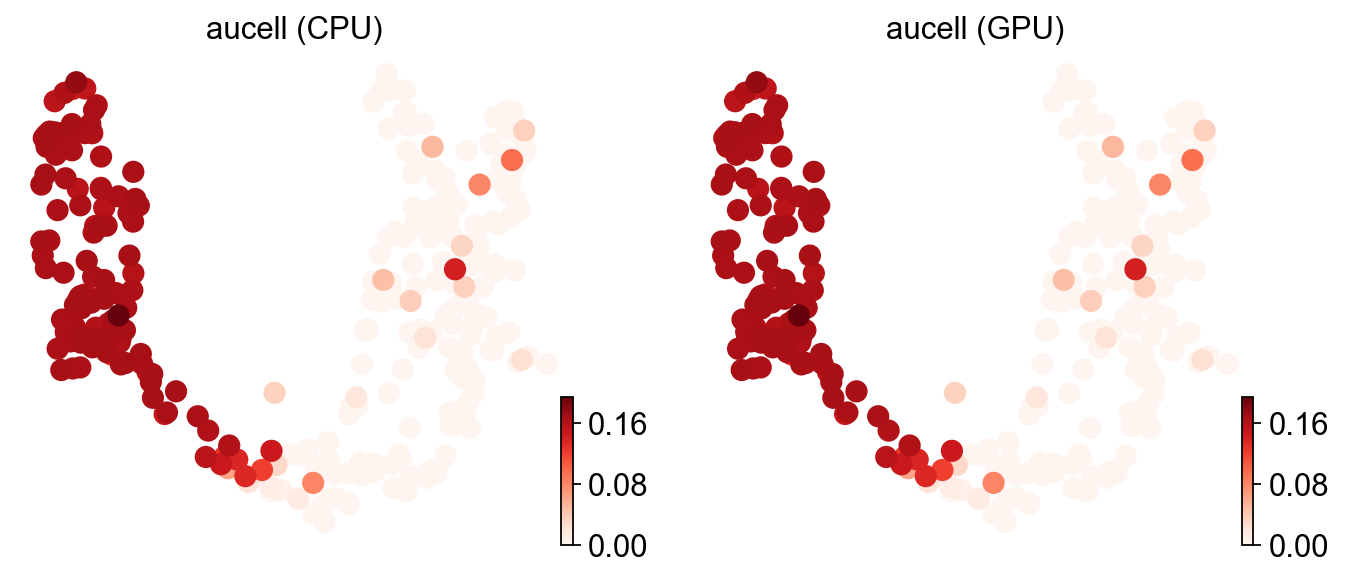

In [8]:
# Side-by-side UMAP: identical patterns => CPU and GPU agree.
ov.pl.umap(adata, color=['aucell (CPU)', 'aucell (GPU)'], cmap='Reds', frameon=False)

## ov.es.ucell

UCell scores each cell by the **Mann-Whitney U-statistic** of the signature genes against the cell's own descending-rank distribution. Genes ranked beyond `maxRank` (default 1500) are clamped, so the score is robust to the long tail of low-expression noise. The result lives in $[0, 1]$, with 1 when every signature gene tops the ranking. Signatures can mix up/down members by suffixing genes with `+` or `-`; the combined score is `max(0, UCell(S⁺) − w_neg · UCell(S⁻))`. Reference: [Andreatta & Carmona, *Comput Struct Biotechnol J* (2021)](https://doi.org/10.1016/j.csbj.2021.06.043).

Both engines are bit-identical on `fp64`. The GPU path computes per-cell ranks on the CPU (scipy `rankdata` with average ties) and vectorises the per-signature U-score as a single `(cells × genes) @ (genes × signatures)` matmul on GPU — ~2× wall-clock on H100 for ≥ 200 signatures × 10k cells × 20k genes.

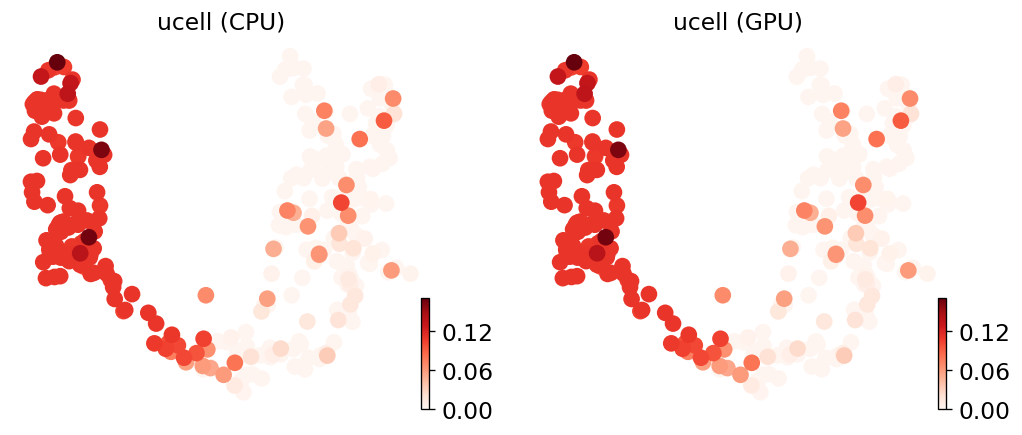

In [ ]:
# CPU pass — the same numpy/scipy kernel that matches R UCell
# (Andreatta & Carmona 2021) bit-for-bit on fp64.
ov.es.ucell(adata, signatures=signatures, engine='cpu')
scores_cpu['ucell'] = adata.obsm['score_ucell'][geneset_name].astype(float).values
adata.obs['ucell (CPU)'] = scores_cpu['ucell']

# Same call with engine='gpu' — CPU-rank + GPU-matmul hybrid path.
ov.es.ucell(adata, signatures=signatures, engine='gpu')
scores_gpu['ucell'] = adata.obsm['score_ucell'][geneset_name].astype(float).values
adata.obs['ucell (GPU)'] = scores_gpu['ucell']

# Side-by-side UMAP: identical patterns => CPU and GPU agree.
ov.pl.umap(adata, color=['ucell (CPU)', 'ucell (GPU)'], cmap='Reds', frameon=False)

## ov.es.gsea

GSEA walks down a per-cell ranked list of features and accumulates a step value that is positive when the gene belongs to the signature $F$ and negative otherwise. With $r_i$ the ranking statistic, $k$ the set size and $l = N - k$ the size of the complement,

$$\delta(F, i) \;=\; \begin{cases} \dfrac{|r_i|}{\sum_{j \in F} |r_j|} & \text{if } i \in F \\[6pt] -\dfrac{1}{l} & \text{if } i \notin F \end{cases}$$

The enrichment score is the running sum's signed extremum,

$$ES \;=\; L_{\arg\max_i |L_i|}, \qquad L_i = \sum_{j \le i} \delta(F, j),$$

with permutation-based significance,

$$p_\text{value} \;=\; \frac{\#\{ES_\text{rand} \ge ES\}}{P}, \qquad NES \;=\; \begin{cases} ES / \mu_{+} & ES > 0 \\ ES / \mu_{-} & ES < 0 \end{cases}$$

The GPU kernel handles the deterministic ES (`times=1`). On the CPU side we pass `times=50` — the numba kernel has a known bug at very small `times` values, but the deterministic ES it computes is the same regardless of the (unused) permutation block. Reference: [Subramanian et al., PNAS (2005)](https://doi.org/10.1073/pnas.0506580102).

In [9]:
# CPU: times=50 to dodge the numba bug at small times; ES is unaffected by the
# permutation count (it's the deterministic running-sum extremum).
ov.es.gsea(adata, signatures=signatures, tmin=3, engine='cpu', times=50)
scores_cpu['gsea'] = adata.obsm['score_gsea'][geneset_name].astype(float).values
adata.obs['gsea (CPU)'] = scores_cpu['gsea']

# GPU: times=1 keeps the kernel on-device (no permutation CPU fallback).
ov.es.gsea(adata, signatures=signatures, tmin=3, engine='gpu', times=1)
scores_gpu['gsea'] = adata.obsm['score_gsea'][geneset_name].astype(float).values
adata.obs['gsea (GPU)'] = scores_gpu['gsea']


╭─ SUMMARY: gsea ────────────────────────────────────────────────────╮
│  Duration: 0.8218s                                                 │
│  Shape:    300 x 14,182 (Unchanged)                                │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● OBSM   │ ✚ padj_gsea (dataframe, 300x1)                         │
│           │ ✚ score_gsea (dataframe, 300x1)                        │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯

╭─ SUMMARY: gsea ────────────────────────────────────────────────────╮
│  Duration: 0.1066s                                                 │
│  Shape:    300 x 14,182 (Unchanged)                                │
│                                                                    │
│  C

X_umap converted to UMAP to visualize and saved to adata.obsm['UMAP']
if you want to use X_umap, please set convert=False


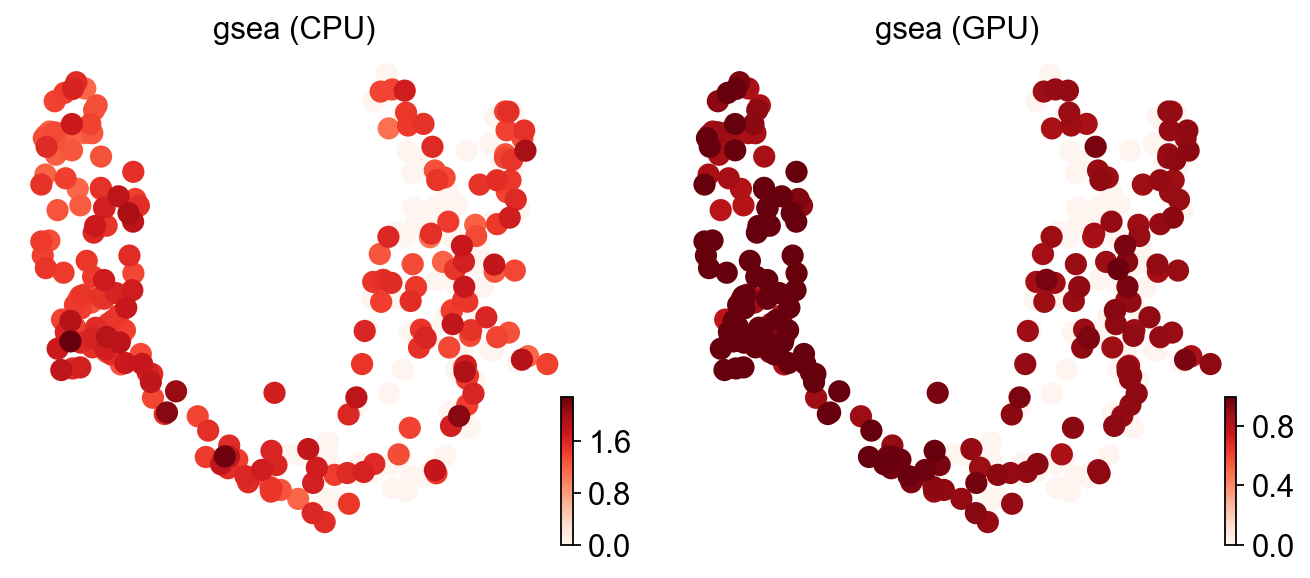

In [10]:
# Note: when times>1 the CPU path returns the *normalised* ES (NES); the GPU path
# at times=1 returns the raw ES. The patterns agree but the scales differ — that's
# why the scatter at the bottom shows a stretched gsea cluster.
ov.pl.umap(adata, color=['gsea (CPU)', 'gsea (GPU)'], cmap='Reds', frameon=False)

## ov.es.gsva

GSVA shares GSEA's $\delta$ formula but takes the **sum of the maximum positive and the minimum negative** deviation rather than the signed extremum. With

$$\delta(F, i) \;=\; \begin{cases} \dfrac{|r_i|}{\sum_{j \in F} |r_j|} & i \in F \\[6pt] -\dfrac{1}{l} & i \notin F \end{cases}, \qquad L = \bigl(\delta(F, i)\bigr)_{i = 1, \dots, N}$$

the enrichment score is

$$ES \;=\; \max_{1 \le i \le N} L_i \;+\; \min_{1 \le i \le N} L_i.$$

Before ranking, features are passed through a non-parametric CDF (Gaussian or Poisson kernel). Reference: [Hänzelmann et al., BMC Bioinf (2013)](https://doi.org/10.1186/1471-2105-14-7).

In [11]:
# CPU: numba kernel with Gaussian KDE pre-transform (the default kcdf).
ov.es.gsva(adata, signatures=signatures, tmin=3, engine='cpu')
scores_cpu['gsva'] = adata.obsm['score_gsva'][geneset_name].astype(float).values
adata.obs['gsva (CPU)'] = scores_cpu['gsva']

# GPU: torch port — same kcdf, same rank tie-breaking, vectorised across cells.
ov.es.gsva(adata, signatures=signatures, tmin=3, engine='gpu')
scores_gpu['gsva'] = adata.obsm['score_gsva'][geneset_name].astype(float).values
adata.obs['gsva (GPU)'] = scores_gpu['gsva']


╭─ SUMMARY: gsva ────────────────────────────────────────────────────╮
│  Duration: 5.4377s                                                 │
│  Shape:    300 x 14,182 (Unchanged)                                │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● OBSM   │ ✚ score_gsva (dataframe, 300x1)                        │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯

╭─ SUMMARY: gsva ────────────────────────────────────────────────────╮
│  Duration: 0.1089s                                                 │
│  Shape:    300 x 14,182 (Unchanged)                                │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ─

X_umap converted to UMAP to visualize and saved to adata.obsm['UMAP']
if you want to use X_umap, please set convert=False


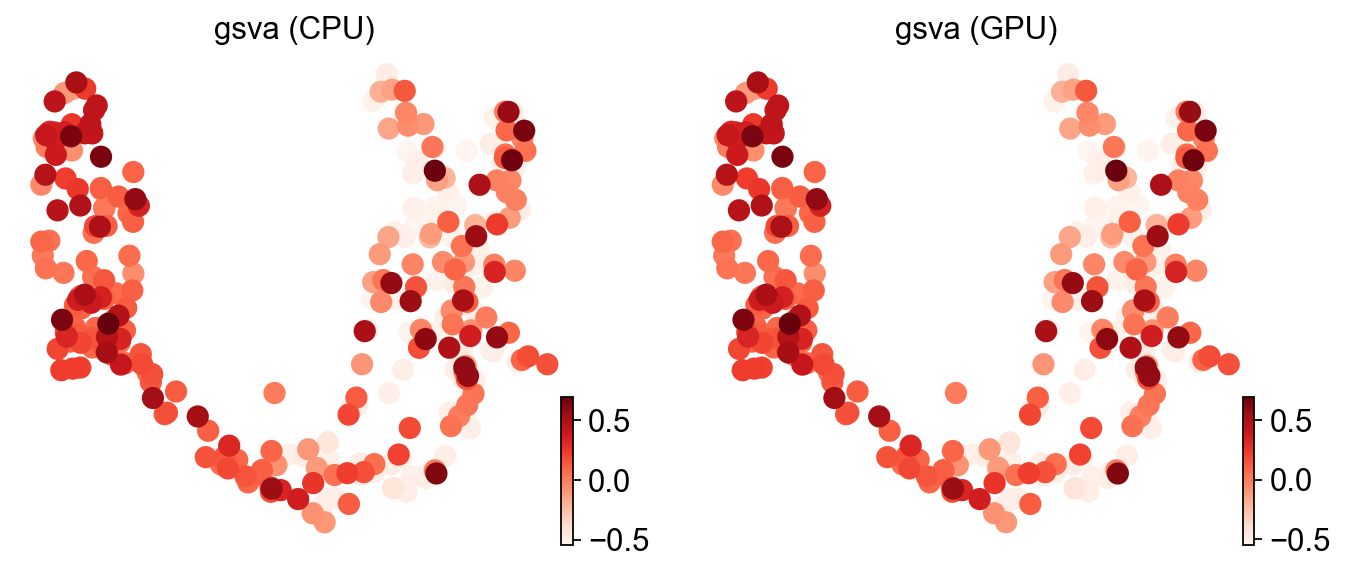

In [12]:
ov.pl.umap(adata, color=['gsva (CPU)', 'gsva (GPU)'], cmap='Reds', frameon=False)

## ov.es.ora

ORA builds a 2×2 contingency table from (significant feature / not) × (in-signature / not). Letting $a, b, c, d$ be the four counts with Haldane–Anscombe correction,

$$OR \;=\; \log\!\left( \dfrac{(a + 0.5) / (b + 0.5)}{(c + 0.5) / (d + 0.5)} \right)$$

and the p-value is a two-tailed Fisher exact test on the table, with Benjamini–Hochberg correction across signatures:

$$p \;=\; P(X \ge a \mid \mathrm{hypergeometric}), \qquad p_\text{adj} \;=\; \mathrm{BH}(p).$$

Reference: [Fisher, J R Stat Soc (1922)](https://doi.org/10.2307/2340521).

In [13]:
# CPU: numba contingency builder + scipy.stats.hypergeom.sf for the tail.
ov.es.ora(adata, signatures=signatures, tmin=3, engine='cpu')
scores_cpu['ora'] = adata.obsm['score_ora'][geneset_name].astype(float).values
adata.obs['ora (CPU)'] = scores_cpu['ora']

# GPU: torch-side contingency + a batched lgamma-based hypergeometric SF
# (hypergeom_sf_torch in omicverse.es._engine) so the survival function never
# round-trips through scipy.
ov.es.ora(adata, signatures=signatures, tmin=3, engine='gpu')
scores_gpu['ora'] = adata.obsm['score_ora'][geneset_name].astype(float).values
adata.obs['ora (GPU)'] = scores_gpu['ora']


╭─ SUMMARY: ora ─────────────────────────────────────────────────────╮
│  Duration: 0.6613s                                                 │
│  Shape:    300 x 14,182 (Unchanged)                                │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● OBSM   │ ✚ padj_ora (dataframe, 300x1)                          │
│           │ ✚ score_ora (dataframe, 300x1)                         │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯

╭─ SUMMARY: ora ─────────────────────────────────────────────────────╮
│  Duration: 0.0827s                                                 │
│  Shape:    300 x 14,182 (Unchanged)                                │
│                                                                    │
│  C

X_umap converted to UMAP to visualize and saved to adata.obsm['UMAP']
if you want to use X_umap, please set convert=False


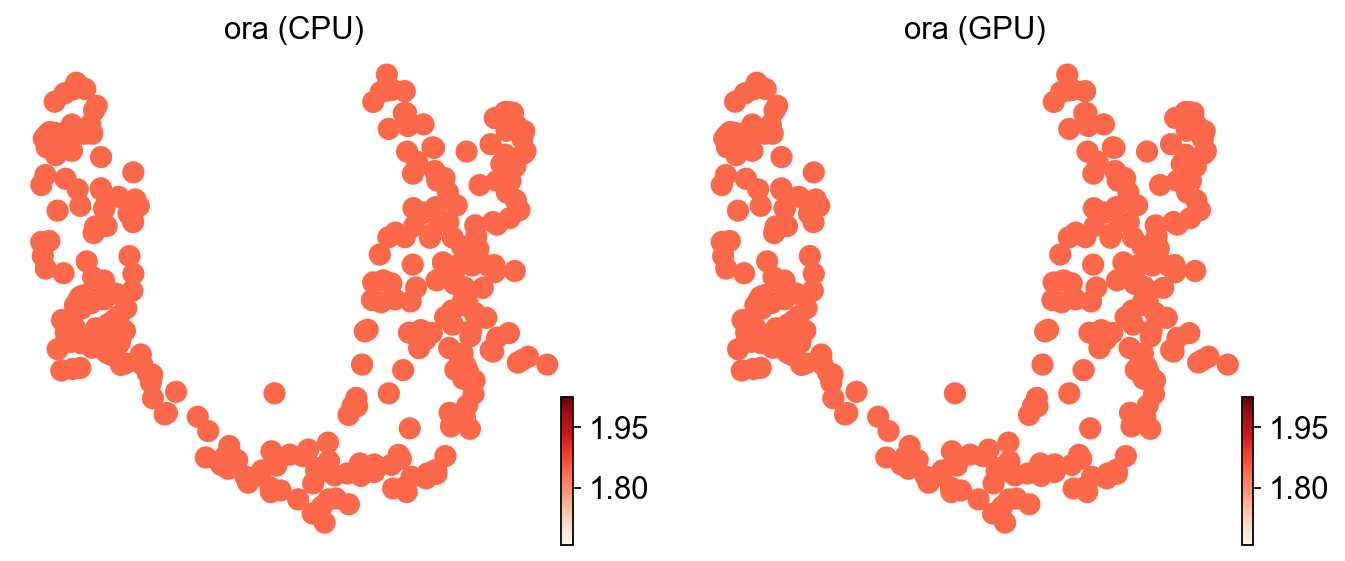

In [14]:
ov.pl.umap(adata, color=['ora (CPU)', 'ora (GPU)'], cmap='Reds', frameon=False)

## ov.es.ulm

ULM fits a univariate linear regression of cell expression on the single signature's weights — features are the observations, expression in the cell is the response. With $y_i$ the expression of feature $i$ and $x_i$ the signature weight,

$$y_i \;=\; \beta_0 + \beta_1\, x_i + \varepsilon, \qquad i = 1, 2, \dots, n,$$

and the score is the t-statistic of the slope,

$$ES \;=\; t_{\beta_1} \;=\; \dfrac{\hat{\beta}_1}{\mathrm{SE}(\hat{\beta}_1)}, \qquad p_\text{value} \;=\; 2 \cdot \mathrm{sf}(|ES|,\, \mathrm{df}).$$

Reference: [Badia-i-Mompel et al., Bioinformatics Advances (2022)](https://doi.org/10.1093/bioadv/vbac016).

In [15]:
# CPU: closed-form OLS slope/t-statistic per (cell × signature).
ov.es.ulm(adata, signatures=signatures, tmin=3, engine='cpu')
scores_cpu['ulm'] = adata.obsm['score_ulm'][geneset_name].astype(float).values
adata.obs['ulm (CPU)'] = scores_cpu['ulm']

# GPU: batched matmul-based OLS over all cells; t-survival via Normal approx
# for df > 100 to skip the incomplete-beta evaluation on-device.
ov.es.ulm(adata, signatures=signatures, tmin=3, engine='gpu')
scores_gpu['ulm'] = adata.obsm['score_ulm'][geneset_name].astype(float).values
adata.obs['ulm (GPU)'] = scores_gpu['ulm']


╭─ SUMMARY: ulm ─────────────────────────────────────────────────────╮
│  Duration: 0.1155s                                                 │
│  Shape:    300 x 14,182 (Unchanged)                                │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● OBSM   │ ✚ padj_ulm (dataframe, 300x1)                          │
│           │ ✚ score_ulm (dataframe, 300x1)                         │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯

╭─ SUMMARY: ulm ─────────────────────────────────────────────────────╮
│  Duration: 0.0459s                                                 │
│  Shape:    300 x 14,182 (Unchanged)                                │
│                                                                    │
│  C

X_umap converted to UMAP to visualize and saved to adata.obsm['UMAP']
if you want to use X_umap, please set convert=False


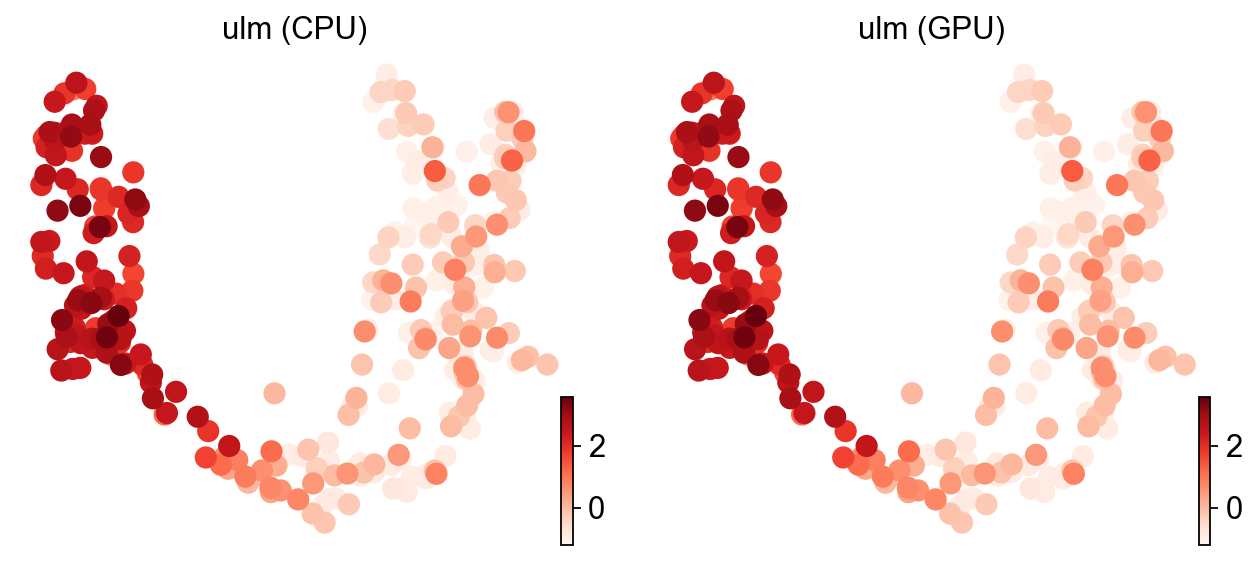

In [16]:
ov.pl.umap(adata, color=['ulm (CPU)', 'ulm (GPU)'], cmap='Reds', frameon=False)

## ov.es.mlm

MLM is the joint variant of ULM — one regression per cell with **all** signatures as covariates at once. The model is

$$y^{(i)} \;=\; \beta_0 + \beta_1\, x_1^{(i)} + \beta_2\, x_2^{(i)} + \cdots + \beta_p\, x_p^{(i)} + \varepsilon,$$

and the score for signature $j$ is its slope's t-statistic,

$$ES_j \;=\; t_{\beta_j} \;=\; \dfrac{\hat{\beta}_j}{\mathrm{SE}(\hat{\beta}_j)}, \qquad p_\text{value} \;=\; 2 \cdot \mathrm{sf}(|ES_j|,\, \mathrm{df}).$$

When signatures overlap, the joint fit deconfounds shared genes. Reference: [Badia-i-Mompel et al., Bioinformatics Advances (2022)](https://doi.org/10.1093/bioadv/vbac016).

In [17]:
# CPU: numba (X^T X)^-1 inverse per cell × t-statistic for each coefficient.
ov.es.mlm(adata, signatures=signatures, tmin=3, engine='cpu')
scores_cpu['mlm'] = adata.obsm['score_mlm'][geneset_name].astype(float).values
adata.obs['mlm (CPU)'] = scores_cpu['mlm']

# GPU: batched torch.linalg.solve per cell + same Normal approx for the t-survival.
ov.es.mlm(adata, signatures=signatures, tmin=3, engine='gpu')
scores_gpu['mlm'] = adata.obsm['score_mlm'][geneset_name].astype(float).values
adata.obs['mlm (GPU)'] = scores_gpu['mlm']


╭─ SUMMARY: mlm ─────────────────────────────────────────────────────╮
│  Duration: 0.1668s                                                 │
│  Shape:    300 x 14,182 (Unchanged)                                │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● OBSM   │ ✚ padj_mlm (dataframe, 300x1)                          │
│           │ ✚ score_mlm (dataframe, 300x1)                         │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯

╭─ SUMMARY: mlm ─────────────────────────────────────────────────────╮
│  Duration: 0.0716s                                                 │
│  Shape:    300 x 14,182 (Unchanged)                                │
│                                                                    │
│  C

X_umap converted to UMAP to visualize and saved to adata.obsm['UMAP']
if you want to use X_umap, please set convert=False


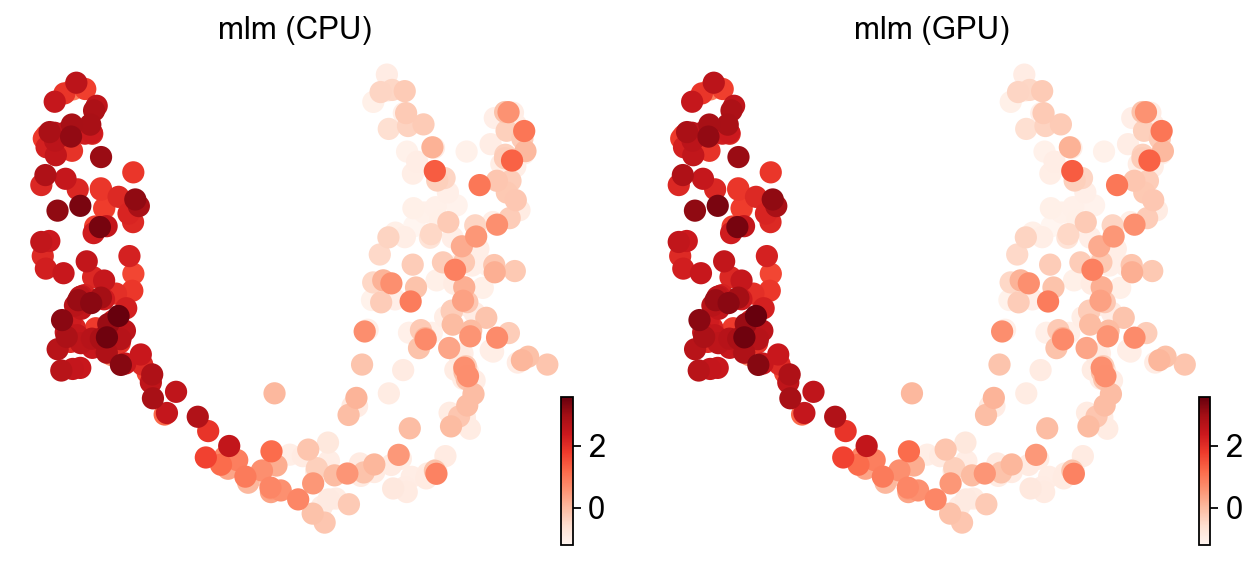

In [18]:
ov.pl.umap(adata, color=['mlm (CPU)', 'mlm (GPU)'], cmap='Reds', frameon=False)

## ov.es.waggr

WAGGR is the simplest scorer: a weighted aggregate of signature genes. With $w_i$ the signature weight of gene $i$ and $x_i$ its expression in the cell,

$$ES \;=\; \dfrac{\sum_{i = 1}^{n} w_i\, x_i}{\sum_{i = 1}^{n} w_i} \quad\text{(``wmean'', default)}, \qquad ES \;=\; \sum_{i = 1}^{n} w_i\, x_i \quad\text{(``wsum'')}.$$

A custom aggregator $ES = f(w_i, x_i)$ is also allowed. Empirical significance is permutation-based:

$$p_\text{value} \;=\; \dfrac{\#\{ES_\text{rand} \ge ES\}}{P}, \qquad NES \;=\; \dfrac{ES - \mu(ES_\text{rand})}{\sigma(ES_\text{rand})}.$$

We pass `times=1` so the GPU kernel only computes the deterministic statistic. Reference: [Badia-i-Mompel et al., Bioinformatics Advances (2022)](https://doi.org/10.1093/bioadv/vbac016).

In [19]:
# CPU: numba weighted mean per (cell × signature); the same path skips the
# permutation block at times=1.
ov.es.waggr(adata, signatures=signatures, tmin=3, engine='cpu', times=1)
scores_cpu['waggr'] = adata.obsm['score_waggr'][geneset_name].astype(float).values
adata.obs['waggr (CPU)'] = scores_cpu['waggr']

# GPU: collapses to a single (cells × features) @ (features × signatures) matmul
# plus per-column normalisation.
ov.es.waggr(adata, signatures=signatures, tmin=3, engine='gpu', times=1)
scores_gpu['waggr'] = adata.obsm['score_waggr'][geneset_name].astype(float).values
adata.obs['waggr (GPU)'] = scores_gpu['waggr']


╭─ SUMMARY: waggr ───────────────────────────────────────────────────╮
│  Duration: 1.1193s                                                 │
│  Shape:    300 x 14,182 (Unchanged)                                │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● OBSM   │ ✚ padj_waggr (dataframe, 300x1)                        │
│           │ ✚ score_waggr (dataframe, 300x1)                       │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯

╭─ SUMMARY: waggr ───────────────────────────────────────────────────╮
│  Duration: 0.0299s                                                 │
│  Shape:    300 x 14,182 (Unchanged)                                │
│                                                                    │
│  C

X_umap converted to UMAP to visualize and saved to adata.obsm['UMAP']
if you want to use X_umap, please set convert=False


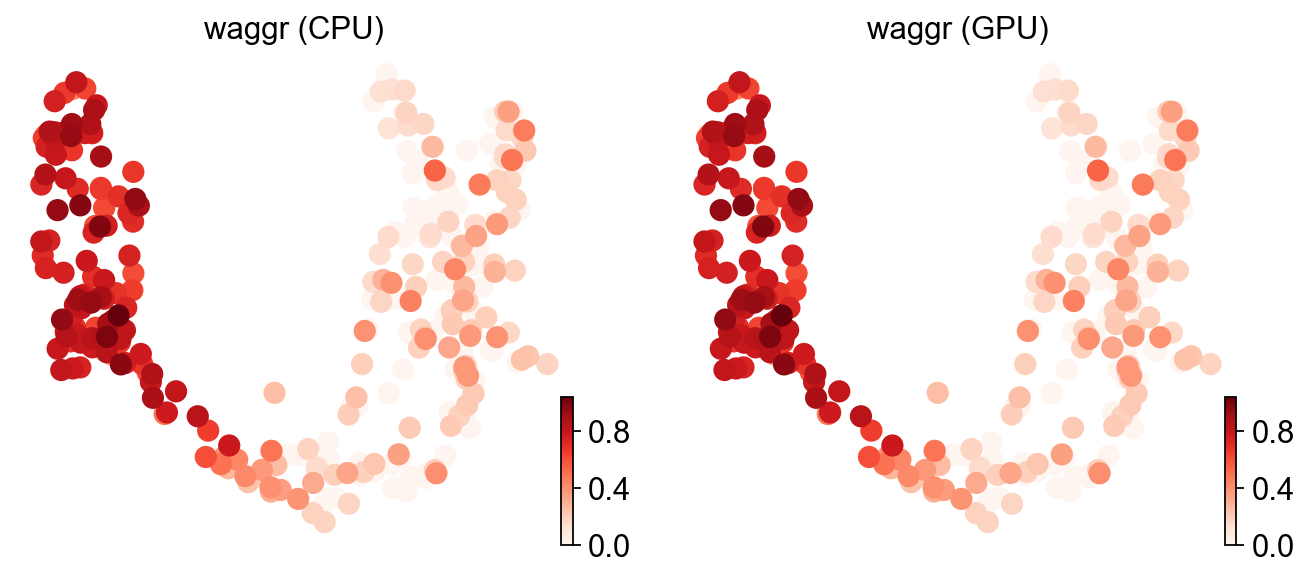

In [20]:
ov.pl.umap(adata, color=['waggr (CPU)', 'waggr (GPU)'], cmap='Reds', frameon=False)

## ov.es.zscore

Z-score standardises the signature mean against the per-cell distribution of all features. With $\mu_s, \mu_p$ the per-cell means of the signature features and of all features, $\sigma$ the per-cell standard deviation across all features, and $m = |F|$ the signature size,

$$ES_{\mathrm{KSEA}} \;=\; \dfrac{(\mu_s - \mu_p)\,\sqrt{m}}{\sigma}, \qquad ES_{\mathrm{RoKAI}} \;=\; \dfrac{\mu_s\,\sqrt{m}}{\sigma}, \qquad p \;=\; 2 \cdot \mathrm{sf}(|ES|).$$

The default omicverse / decoupler form is the KSEA variant. Reference: [Yılmaz et al., Nat Commun (2021)](https://doi.org/10.1038/s41467-021-21211-6).

In [21]:
# CPU: numba per-cell mean / std / matmul against the binary signature mask.
ov.es.zscore(adata, signatures=signatures, tmin=3, engine='cpu')
scores_cpu['zscore'] = adata.obsm['score_zscore'][geneset_name].astype(float).values
adata.obs['zscore (CPU)'] = scores_cpu['zscore']

# GPU: torch.std_mean fused with a matmul; survival via torch.special.erfc.
ov.es.zscore(adata, signatures=signatures, tmin=3, engine='gpu')
scores_gpu['zscore'] = adata.obsm['score_zscore'][geneset_name].astype(float).values
adata.obs['zscore (GPU)'] = scores_gpu['zscore']


╭─ SUMMARY: zscore ──────────────────────────────────────────────────╮
│  Duration: 0.0749s                                                 │
│  Shape:    300 x 14,182 (Unchanged)                                │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● OBSM   │ ✚ padj_zscore (dataframe, 300x1)                       │
│           │ ✚ score_zscore (dataframe, 300x1)                      │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯



╭─ SUMMARY: zscore ──────────────────────────────────────────────────╮
│  Duration: 0.0368s                                                 │
│  Shape:    300 x 14,182 (Unchanged)                                │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
╰────────────────────────────────────────────────────────────────────╯


X_umap converted to UMAP to visualize and saved to adata.obsm['UMAP']
if you want to use X_umap, please set convert=False


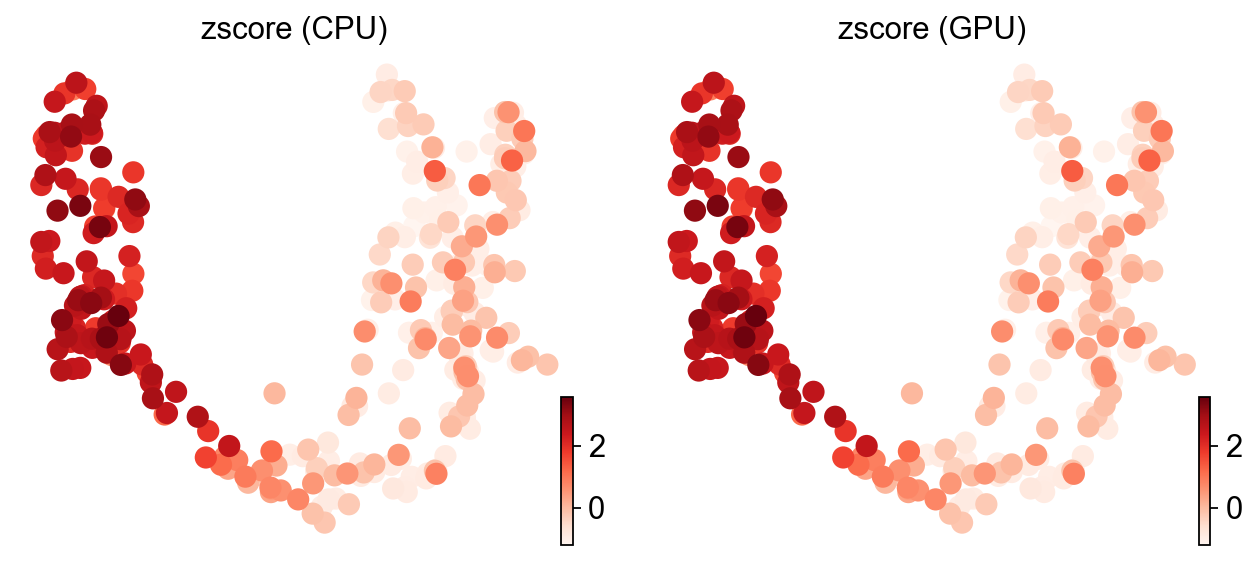

In [22]:
ov.pl.umap(adata, color=['zscore (CPU)', 'zscore (GPU)'], cmap='Reds', frameon=False)

## ov.es.viper

VIPER treats the signature as a regulon and computes an analytical rank-based enrichment (aREA) score combining a magnitude term and a directional term, with optional pleiotropy correction.

Normalise the interaction weights and likelihoods,

$$w \;\leftarrow\; w / \max(|w|), \qquad l_\text{orig} \;=\; \mathbf{1}_{w \neq 0}, \qquad l \;=\; \dfrac{l_\text{orig}}{\sum_{i=1}^{k}\bigl(l_i / \max(l_\text{orig})\bigr) \, \max(l_\text{orig})}.$$

Build the rank-derived quantile transform,

$$q^{\text{norm}} \;=\; \Phi^{-1}\!\bigl(2\,|q - 0.5| + (1 + \max(|q - 0.5|))\bigr),$$

then assemble the magnitude and directional terms,

$$S_1 \;=\; \sum_{i=1}^{k} q^{\text{norm}}_i \, l_i \, (1 - |w_i|), \qquad S_2 \;=\; \sum_{i=1}^{k} w_i \, l_i \, \Phi^{-1}(q_i),$$

combine into $S_3$, scale by likelihood mass, and convert to a p-value,

$$S_3 \;=\; \begin{cases} (|S_2| + S_1)\,\mathrm{sgn}(S_2) & S_1 > 0 \\ S_2 & S_1 \le 0 \end{cases}, \qquad ES \;=\; S_3 \sqrt{\sum_{i=1}^{k} l_{\text{orig},\,i}^{2}}, \qquad p \;=\; \Phi(ES).$$

When pleiotropy correction is enabled, a pairwise score $PS$ down-weights overlapping regulators:

$$PS \;=\; \begin{cases} \bigl(1 + |\log_{10}(p_B) - \log_{10}(p_A)|\bigr)^{-20/n_a} & p_A < p_B \\ \bigl(1 + |\log_{10}(p_A) - \log_{10}(p_B)|\bigr)^{-20/n_b} & p_A > p_B \end{cases}$$

Reference: [Alvarez et al., Nat Genet (2016)](https://doi.org/10.1038/ng.3593).

In [23]:
# CPU: full numba aREA + per-cell pleiotropy refinement loop.
ov.es.viper(adata, signatures=signatures, tmin=3, engine='cpu')
scores_cpu['viper'] = adata.obsm['score_viper'][geneset_name].astype(float).values
adata.obs['viper (CPU)'] = scores_cpu['viper']

# GPU: aREA runs on torch (rank + erfinv ppf + two GEMMs); the pleiotropy loop
# falls back to CPU because its sub-network shapes are cell-dependent.
ov.es.viper(adata, signatures=signatures, tmin=3, engine='gpu')
scores_gpu['viper'] = adata.obsm['score_viper'][geneset_name].astype(float).values
adata.obs['viper (GPU)'] = scores_gpu['viper']


╭─ SUMMARY: viper ───────────────────────────────────────────────────╮
│  Duration: 0.3006s                                                 │
│  Shape:    300 x 14,182 (Unchanged)                                │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● OBSM   │ ✚ padj_viper (dataframe, 300x1)                        │
│           │ ✚ score_viper (dataframe, 300x1)                       │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯

╭─ SUMMARY: viper ───────────────────────────────────────────────────╮
│  Duration: 0.058s                                                  │
│  Shape:    300 x 14,182 (Unchanged)                                │
│                                                                    │
│  C

X_umap converted to UMAP to visualize and saved to adata.obsm['UMAP']
if you want to use X_umap, please set convert=False


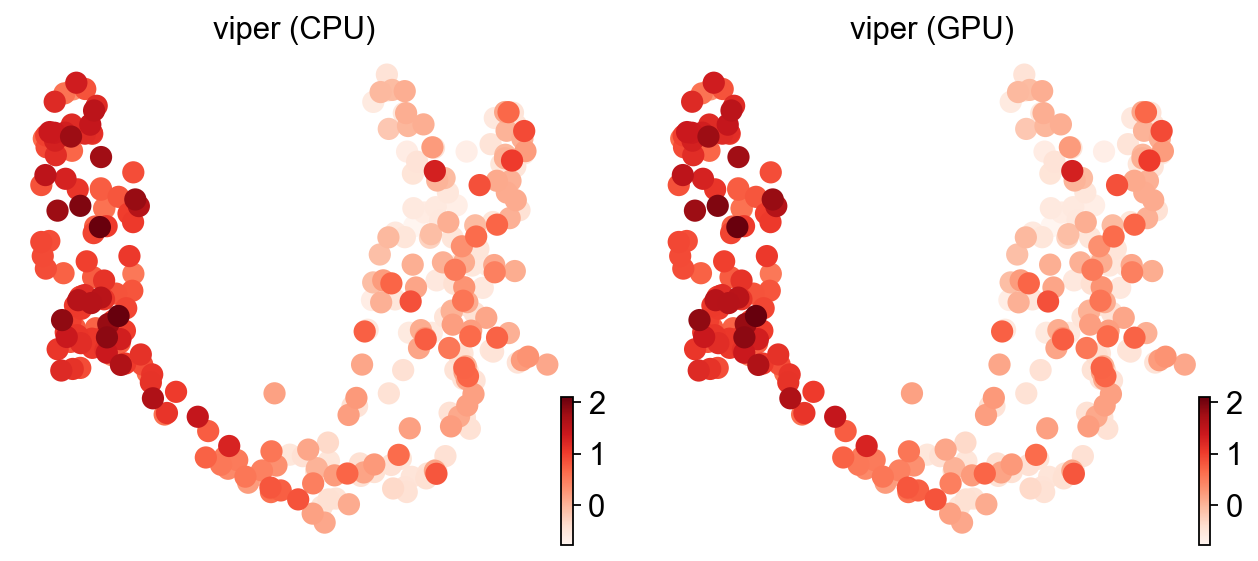

In [24]:
ov.pl.umap(adata, color=['viper (CPU)', 'viper (GPU)'], cmap='Reds', frameon=False)

## ov.es.mdt

MDT fits one gradient-boosted decision tree (XGBoost) per cell with all signatures as covariates, then reports the per-signature **feature importance** of the trained model. With $g_s$ the split-gain attributable to signature $j$ across all trees,

$$ES_j \;=\; \dfrac{\sum_{\text{splits on } j} g_s}{\sum_{j'} \sum_{\text{splits on } j'} g_s}.$$

MDT's CPU baseline fits one `xgboost.XGBRegressor` per cell, which is impractical at scRNA scale (minutes per thousand cells) — exactly the bottleneck the torch GBDT in `_engine.py` exists to remove. We run GPU only here; the CPU column in the closing accuracy table is therefore blank for MDT. References: [Badia-i-Mompel et al., Bioinformatics Advances (2022)](https://doi.org/10.1093/bioadv/vbac016); [Chen & Guestrin, KDD (2016)](https://doi.org/10.1145/2939672.2939785).

In [25]:
# GPU only — the torch GBDT in omicverse.es._engine fits all cells in parallel.
ov.es.mdt(adata, signatures=signatures, tmin=3, engine='gpu')
scores_gpu['mdt'] = adata.obsm['score_mdt'][geneset_name].astype(float).values
adata.obs['mdt (GPU)'] = scores_gpu['mdt']


╭─ SUMMARY: mdt ─────────────────────────────────────────────────────╮
│  Duration: 1.6364s                                                 │
│  Shape:    300 x 14,182 (Unchanged)                                │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● OBSM   │ ✚ score_mdt (dataframe, 300x1)                         │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯


X_umap converted to UMAP to visualize and saved to adata.obsm['UMAP']
if you want to use X_umap, please set convert=False


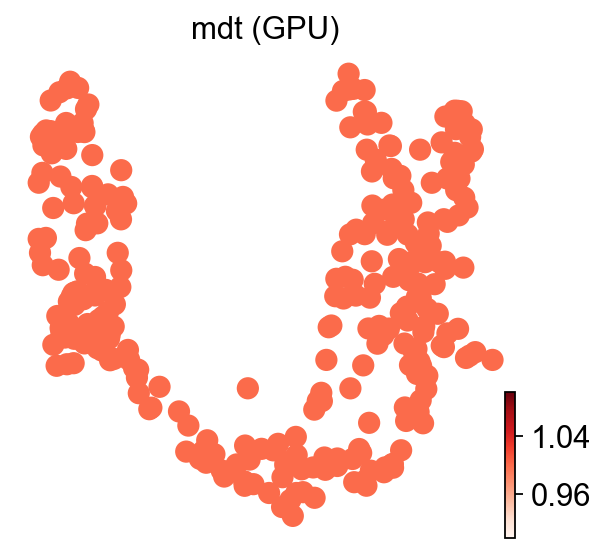

In [26]:
ov.pl.umap(adata, color='mdt (GPU)', cmap='Reds', frameon=False)

## ov.es.udt

UDT fits a univariate gradient-boosted decision tree per (cell × signature) using the single signature's weights as the regressor, and reports the model's coefficient of determination,

$$ES \;=\; R^{2} \;=\; 1 - \dfrac{\sum_{g} (y_g - \hat{y}_g)^{2}}{\sum_{g} (y_g - \bar{y})^{2}}.$$

Like MDT, UDT fits one `xgboost` per (cell × signature) — even more expensive at scale than MDT — so we run GPU only here too. References: [Badia-i-Mompel et al., Bioinformatics Advances (2022)](https://doi.org/10.1093/bioadv/vbac016); [Chen & Guestrin, KDD (2016)](https://doi.org/10.1145/2939672.2939785).

In [27]:
# GPU only — torch GBDT, one parallel model per (cell × signature).
ov.es.udt(adata, signatures=signatures, tmin=3, engine='gpu')
scores_gpu['udt'] = adata.obsm['score_udt'][geneset_name].astype(float).values
adata.obs['udt (GPU)'] = scores_gpu['udt']


╭─ SUMMARY: udt ─────────────────────────────────────────────────────╮
│  Duration: 0.1838s                                                 │
│  Shape:    300 x 14,182 (Unchanged)                                │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● OBSM   │ ✚ score_udt (dataframe, 300x1)                         │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯


X_umap converted to UMAP to visualize and saved to adata.obsm['UMAP']
if you want to use X_umap, please set convert=False


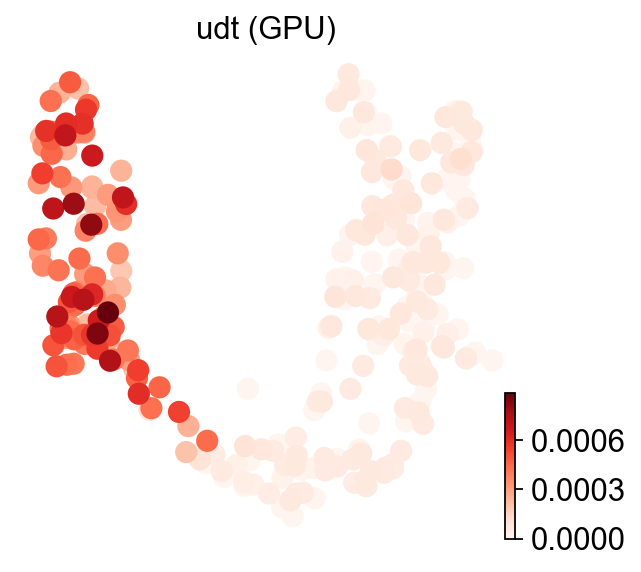

In [28]:
ov.pl.umap(adata, color='udt (GPU)', cmap='Reds', frameon=False)

## Part.3 CPU vs GPU scatter — all methods with a CPU baseline

Each point is one cell; x = CPU score, y = GPU score. Points on the diagonal mean perfect agreement. Different colours = different methods.

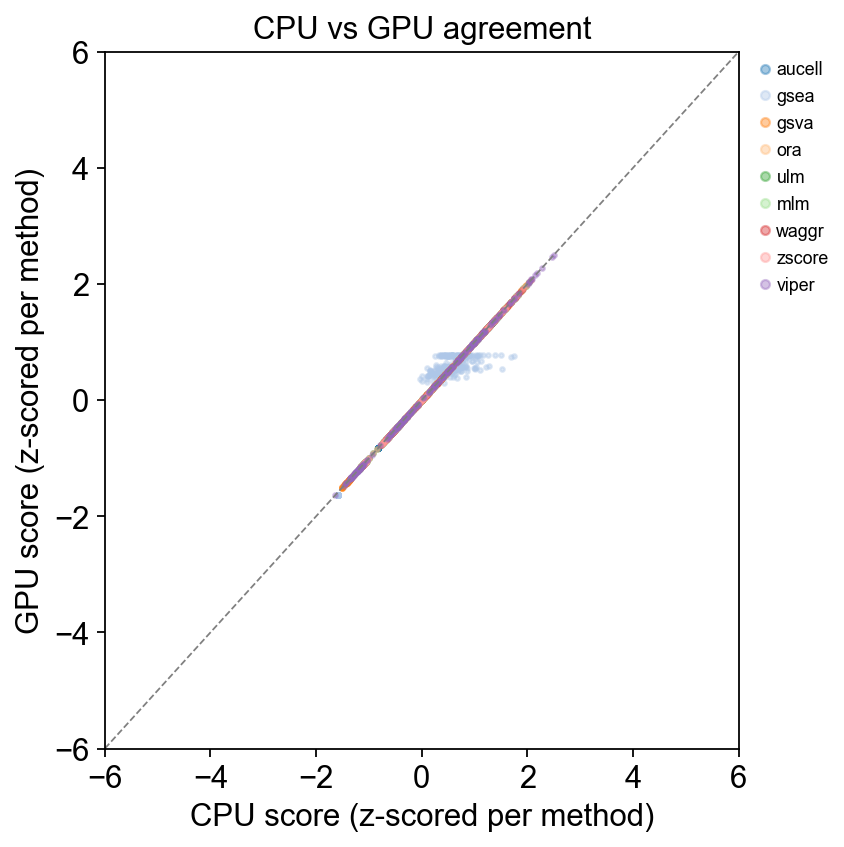

In [29]:
import matplotlib.pyplot as plt

# Only the nine methods with a tractable CPU baseline appear here; mdt / udt
# show up in their own UMAP panels above (GPU only).
_methods = [m for m in scores_gpu if m in scores_cpu]
_cmap = plt.get_cmap('tab20')
fig, ax = plt.subplots(figsize=(5.5, 5.5))
for _i, _m in enumerate(_methods):
    _x = scores_cpu[_m]
    _y = scores_gpu[_m]
    # z-score per method so methods on different scales share an axis.
    _xz = (_x - _x.mean()) / (_x.std() + 1e-12)
    _yz = (_y - _y.mean()) / (_y.std() + 1e-12)
    ax.scatter(_xz, _yz, s=4, alpha=0.4, label=_m, color=_cmap(_i % _cmap.N))
ax.plot([-6, 6], [-6, 6], '--', color='grey', lw=0.8)  # y = x reference
ax.set_xlim(-6, 6); ax.set_ylim(-6, 6)
ax.set_xlabel('CPU score (z-scored per method)')
ax.set_ylabel('GPU score (z-scored per method)')
ax.set_title('CPU vs GPU agreement')
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=8, markerscale=2)
plt.tight_layout()
plt.show()

## Part.4 CPU vs GPU accuracy table

Each call cell above already prints the engine's wall time in its SUMMARY box, so the table below focuses on numerical agreement (Pearson, Spearman, RMSE / range).

In [30]:
import pandas as pd
from scipy.stats import pearsonr, spearmanr

rows = []
for _m in [m for m in scores_gpu if m in scores_cpu]:
    _x = scores_cpu[_m]
    _y = scores_gpu[_m]
    # RMSE normalised by the CPU score's range so we can compare across
    # methods whose ES values live on different scales.
    _rmse = float(np.sqrt(np.mean((_x - _y) ** 2)))
    _rng = float(_x.max() - _x.min())
    rows.append({
        'method': _m,
        'pearson r': round(pearsonr(_x, _y)[0], 4),
        'spearman r': round(spearmanr(_x, _y)[0], 4),
        'rmse / range': round(_rmse / _rng if _rng > 0 else 0.0, 4),
    })
pd.DataFrame(rows).set_index('method')

,pearson r,spearman r,rmse / range
method,,,
aucell,1.0000,1.0000,0.0000
gsea,0.9747,0.8019,0.2224
gsva,1.0000,1.0000,0.0001
ora,NaN,NaN,0.0000
ulm,1.0000,1.0000,0.0000
mlm,1.0000,1.0000,0.0000
waggr,1.0000,1.0000,0.0000
zscore,1.0000,1.0000,0.0000
viper,1.0000,1.0000,0.0000
